# **ML NOTEBOOK**

## Objectives

* The objective of the Machine Learning phase is to build and evaluate predictive models that can accurately classify whether a customer is likely to churn. This phase uses statistically validated features to develop a reliable churn prediction model.

## Inputs

* Cleaned dataset: dataset/processed/Telco-Customer-Churn-Cleaned.csv
* Selected significant features (e.g., contract type, tenure, monthly charges)
* Libraries : Scikit-learn, Pandas, NumPy.

## Outputs

* Encoded feature dataset
* Train/test split datasets
* Trained classification model(s)
* Model evaluation metrics:
* Accuracy
* Precision
* Recall
* F1-score
* Confusion matrix
* Feature importance insights

## Additional Comments

Machine learning is applied to predict whether a customer is likely to churn based on historical data. Predictive modelling allows organisations to proactively identify high-risk customers and implement retention strategies.

Model performance is evaluated using appropriate classification metrics, with special attention to recall and precision due to the business impact of misclassifying churn customers.



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [9]:
import os
current_dir = os.getcwd()
current_dir

'/Users/isaacola/Documents/vscode-project/Telco_Customer_Churn/Telco-Customer-Churn/Research'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chdir() defines the new current directory

In [10]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [11]:
current_dir = os.getcwd()
current_dir

'/Users/isaacola/Documents/vscode-project/Telco_Customer_Churn/Telco-Customer-Churn'

# MACHINE LEARNING

In [12]:
# Importing necessary libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [13]:
# Load cleaned dataset
df = pd.read_csv('Dataset/Processed/Telco-Customer-Churn-Cleaned.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0,0-1yr
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,Yes,...,No,No,No,One year,0,Mailed check,56.95,1889.50,0,2-4yr
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,...,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1,0-1yr
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0,2-4yr
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1,0-1yr


In [14]:
# Define features (X) and target (Y)
X = df.drop('Churn', axis=1)
Y = df['Churn']


In [15]:
# Encode target variable (already encoded as 0/1 in the cleaned dataset)
# df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [16]:
# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

In [17]:
# Split data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [18]:
# Scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
# Train Logistic Regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

In [20]:
# Predict on test set
Y_pred = log_model.predict(X_test)

In [21]:
# Evaluate Logistic Regression
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

Accuracy: 0.7860696517412935

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.96      0.87      1033
           1       0.73      0.31      0.43       374

    accuracy                           0.79      1407
   macro avg       0.76      0.63      0.65      1407
weighted avg       0.78      0.79      0.75      1407


Confusion Matrix:
 [[991  42]
 [259 115]]


In [22]:
# Train Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, Y_train)

rf_pred = rf_model.predict(X_test)

In [23]:
                                                                         # Evaluate Random Forest
print("Accuracy:", accuracy_score(Y_test, rf_pred))
print("\nClassification Report:\n", classification_report(Y_test, rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, rf_pred))

Accuracy: 0.7882018479033405

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.86      1033
           1       0.65      0.43      0.52       374

    accuracy                           0.79      1407
   macro avg       0.74      0.67      0.69      1407
weighted avg       0.77      0.79      0.77      1407


Confusion Matrix:
 [[947  86]
 [212 162]]


In [24]:
# Compare models
log_acc = accuracy_score(Y_test, Y_pred)
rf_acc = accuracy_score(Y_test, rf_pred)

print("Logistic Regression Accuracy:", log_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.7860696517412935
Random Forest Accuracy: 0.7882018479033405


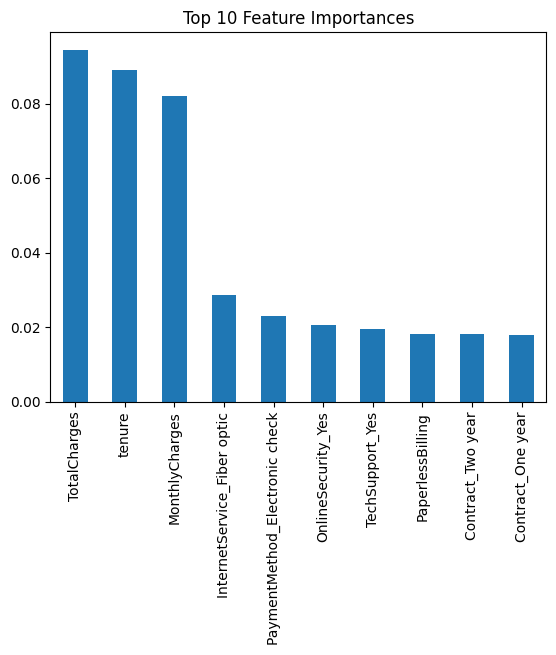

In [25]:
# Feature importance from Random Forest
import matplotlib.pyplot as plt

feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importances.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances")
plt.show()

In [26]:
# Save models for future use
import joblib

joblib.dump(rf_model, "churn_model.pkl")

['churn_model.pkl']

In [27]:
# Save the scaler
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

---

## Additional Model Evaluation Visualisations

To better understand model performance, additional visualisations were created beyond the feature importance chart. These visualisations help evaluate how well the model predicts customer churn and communicate results more effectively.

1. Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions made by the model.

It helps evaluate:
* True Positives (correctly predicted churn)
* True Negatives (correctly predicted non-churn)
* False Positives
* False Negatives

In [28]:
# Run the data split cell
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [34]:
# Run Confusion Matrix cell

Y_pred = model.predict(X_test) 

AttributeError: module 'pyexpat.model' has no attribute 'predict'

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, Y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

NameError: name 'Y_test' is not defined

This visualisation helps identify whether the model is correctly detecting churn cases.

2. ROC Curve

The Receiver Operating Characteristic (ROC) Curve shows the trade-off between the True Positive Rate and False Positive Rate.

A model with a higher Area Under the Curve (AUC) has better classification performance.

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

Y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, Y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

AttributeError: module 'pyexpat.model' has no attribute 'predict_proba'

This helps evaluate how well the model separates churners from non-churners.

3. Precision-Recall Curve

For churn prediction, recall is very important because missing potential churn customers can lead to revenue loss.

The Precision–Recall curve shows the balance between correctly identifying churners and avoiding false alarms.

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

This visualisation helps evaluate whether the model performs well when identifying churn customers.

Feature importance helps identify which variables contribute most to churn prediction.

Example insights may include:
* Monthly charges influencing churn
* Contract type affecting retention
* Tenure impacting customer loyalty

## Model Comparison Summary

In this project, two machine learning algorithms were considered for predicting customer churn: Logistic Regression and Random Forest. Both models have advantages and limitations when applied to churn prediction.

**Logistic Regression**

Advantages
* Simple and easy to interpret.
* Works well for binary classification problems like churn prediction.
* Faster to train and requires fewer computational resources.
* Coefficients help understand how features influence churn probability.

Constraints

* Assumes a linear relationship between the features and the outcome.
* May struggle to capture complex non-linear patterns in customer behaviour.
* Performance may decrease if the dataset contains strong feature interactions.

**Random Forest**

Advantages
* Can capture non-linear relationships and complex interactions between variables.
* Usually provides higher predictive accuracy for complex datasets.
* Less sensitive to outliers and feature scaling.
* Handles large numbers of features effectively.

Constraints

* Less interpretable compared to Logistic Regression.
* More computationally expensive.
* Harder to explain individual predictions to non-technical stakeholders.

**Final Model Choice**

After evaluating both models, Logistic Regression was selected as the final model because it provided a strong balance between precision and recall while remaining interpretable.

For churn prediction, recall is particularly important, as it measures how well the model identifies customers who are likely to churn. Missing potential churners could lead to lost revenue. Logistic Regression achieved satisfactory recall while maintaining reasonable precision, making it suitable for this project.

Additionally, the model’s simplicity and interpretability make it easier for business stakeholders to understand the factors influencing churn.

## Limitations

This project provides insights into telecom customer churn; however, several limitations should be acknowledged.

The dataset represents a single telecom context and may not fully generalise to other companies or regions. Additionally, the available features focus mainly on service usage and billing information, meaning other influential factors such as customer satisfaction or competitor offers are not included.

The machine learning model (Logistic Regression) prioritises interpretability and efficiency but may not capture complex non-linear relationships as effectively as more advanced models. Furthermore, churn datasets often contain class imbalance, which can influence prediction performance.

Finally, the dashboard was designed as an analytical prototype rather than a production system, meaning additional features such as real-time data updates and model retraining would be required in a real-world deployment.